<a href="https://colab.research.google.com/github/UKD1211/Tier_N_Supplier_Visibility_Risk_Pred/blob/main/supplier_risk_pred_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd
import numpy as np


In [91]:
df_main= pd.read_csv("/content/final_dataset_main.csv")

In [92]:
df_main.drop(columns = ['Unnamed: 0'], inplace = True)

In [93]:
df_main

,supplier_id,tier,state,cluster,stage,state_risk_cal,SDG_2023_24,labour_intensity,informality,visibility,cost_pressure,risk_score,high_risk
0,T1_000,1,Andhra Pradesh,Cotton Belt,Raw,0.633688,74,0.2324,0.3917,0.9305,0.3066,0.3084,0
1,T1_001,1,Karnataka,Mysore Silk,Raw,0.560140,75,0.2790,0.3184,0.9153,0.2723,0.2847,0
2,T1_002,1,Telangana,Cotton Belt,Raw,0.585616,74,0.1768,0.3193,0.8907,0.3214,0.2718,0
3,T1_003,1,Karnataka,Mysore Silk,Raw,0.560140,75,0.1138,0.3422,0.8888,0.1884,0.2330,0
4,T1_004,1,Karnataka,Mysore Silk,Raw,0.560140,75,0.1546,0.2794,0.8718,0.2998,0.2463,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,T4_025,4,Karnataka,Bangalore,Garment,0.560137,75,0.9150,0.7783,0.1043,0.7058,0.8654,1
116,T4_026,4,Tamil Nadu,Tiruppur,Garment,0.501682,78,0.9807,0.6452,0.1152,0.6696,0.8157,1
117,T4_027,4,Uttar Pradesh,Noida,Garment,0.917599,67,0.9362,0.8323,0.0540,0.8182,0.9347,1
118,T4_028,4,Tamil Nadu,Tiruppur,Garment,0.501682,78,1.0000,0.5751,0.0950,0.7490,0.8130,1


In [94]:
df_main['high_risk'].value_counts(normalize = True)*100

,proportion
high_risk,
0,72.5
1,27.5


In [95]:
df_main.drop(columns = ['supplier_id', 'state', 'cluster', 'risk_score', 'stage'], inplace = True)

In [96]:
df_main

,tier,state_risk_cal,SDG_2023_24,labour_intensity,informality,visibility,cost_pressure,high_risk
0,1,0.633688,74,0.2324,0.3917,0.9305,0.3066,0
1,1,0.560140,75,0.2790,0.3184,0.9153,0.2723,0
2,1,0.585616,74,0.1768,0.3193,0.8907,0.3214,0
3,1,0.560140,75,0.1138,0.3422,0.8888,0.1884,0
4,1,0.560140,75,0.1546,0.2794,0.8718,0.2998,0
...,...,...,...,...,...,...,...,...
115,4,0.560137,75,0.9150,0.7783,0.1043,0.7058,1
116,4,0.501682,78,0.9807,0.6452,0.1152,0.6696,1
117,4,0.917599,67,0.9362,0.8323,0.0540,0.8182,1
118,4,0.501682,78,1.0000,0.5751,0.0950,0.7490,1


In [97]:
X = df_main.drop(columns = ['high_risk'])
y = df_main['high_risk']

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

In [100]:
X_train

,tier,state_risk_cal,SDG_2023_24,labour_intensity,informality,visibility,cost_pressure
65,3,0.608607,73,0.6379,0.5580,0.2795,0.6005
69,3,0.608607,73,0.8035,0.6143,0.2923,0.5734
106,4,0.917599,67,0.9018,0.8911,0.1137,0.9155
96,4,0.501682,78,0.9671,0.6129,0.1375,0.6882
32,2,0.693935,74,0.4225,0.5019,0.5014,0.4324
...,...,...,...,...,...,...,...
119,4,0.917599,67,1.0000,0.8876,0.1224,0.8626
24,1,0.720219,70,0.2003,0.4249,0.8953,0.3611
49,2,0.501682,78,0.5029,0.3566,0.4771,0.3884
78,3,0.608607,73,0.8653,0.6456,0.3004,0.6441


In [101]:
y_train.value_counts(normalize = True)*100

,proportion
high_risk,
0,72.916667
1,27.083333


In [102]:
y_test.value_counts(normalize = True)*100

,proportion
high_risk,
0,70.833333
1,29.166667


In [103]:
#EDA #distribution of the risk here

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", context="talk")

In [122]:
test_df = pd.read_csv("/content/final_dataset_main.csv")

<Axes: xlabel='risk_score', ylabel='Density'>

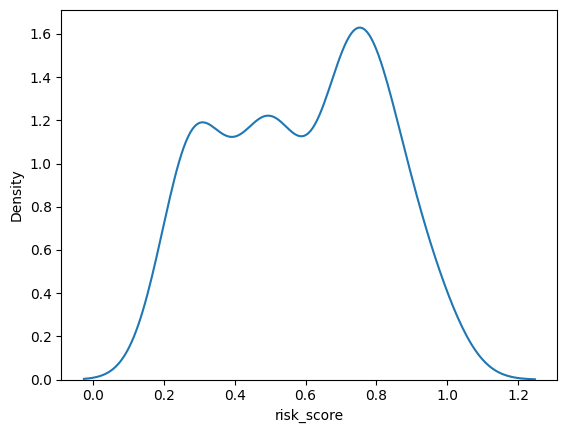

In [112]:
sns.kdeplot(test_df['risk_score'])

<Axes: xlabel='high_risk'>

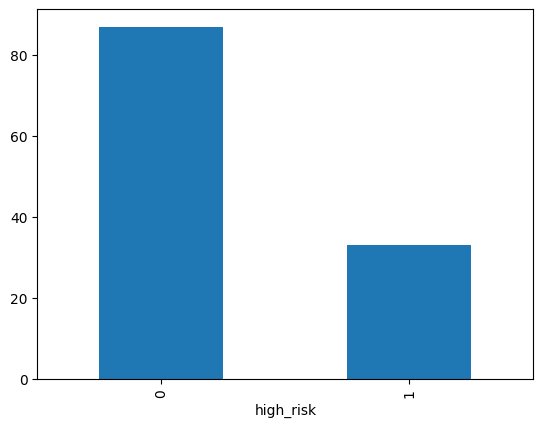

In [114]:
df_main['high_risk'].value_counts().plot(kind = 'bar')

/tmp/ipykernel_6354/1520842756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


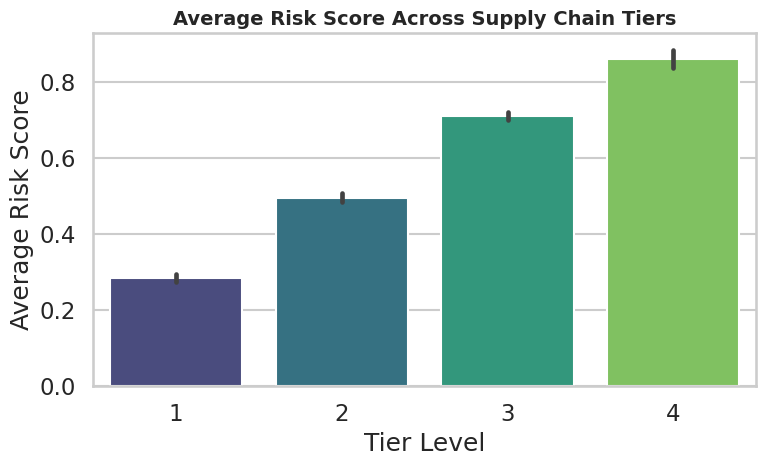

In [123]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='tier',
    y='risk_score',
    data=test_df,
    palette='viridis'   # smooth professional gradient
)

plt.title("Average Risk Score Across Supply Chain Tiers", fontsize=14, weight='bold')
plt.xlabel("Tier Level")
plt.ylabel("Average Risk Score")

plt.tight_layout()
plt.savefig("tier_vs_risk_bar.png", dpi=300)  # save for PPT
plt.show()

/tmp/ipykernel_6354/2631422158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


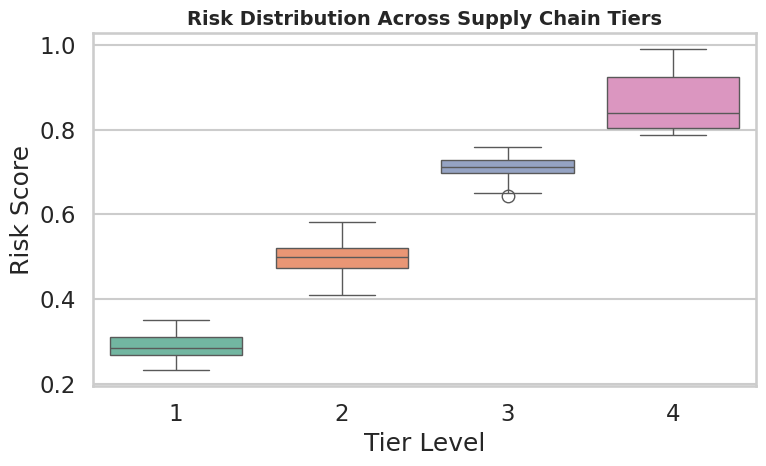

In [126]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='tier',
    y='risk_score',
    data=test_df,
    palette='Set2'   # distinct colors for tiers
)

plt.title("Risk Distribution Across Supply Chain Tiers", fontsize=14, weight='bold')
plt.xlabel("Tier Level")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.savefig("tier_vs_risk_box.png", dpi=300)
plt.show()

In [128]:
pd.crosstab(test_df['tier'], test_df['high_risk'])

high_risk,0,1
tier,,
1,30,0
2,30,0
3,27,3
4,0,30


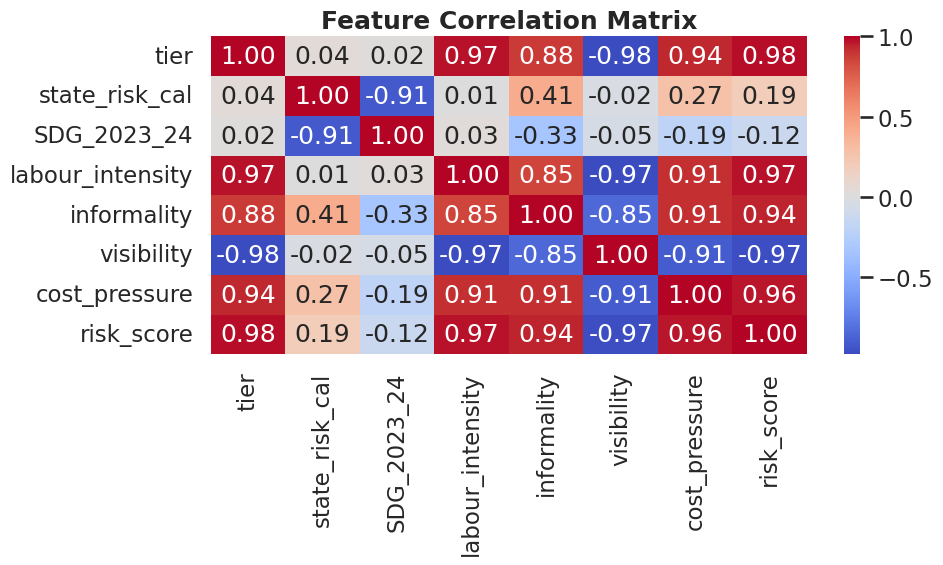

In [131]:
plt.figure(figsize=(10,6))
df_corr = test_df.drop(columns=['supplier_id', 'state', 'cluster', 'stage', 'Unnamed: 0', 'high_risk'])
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix", weight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

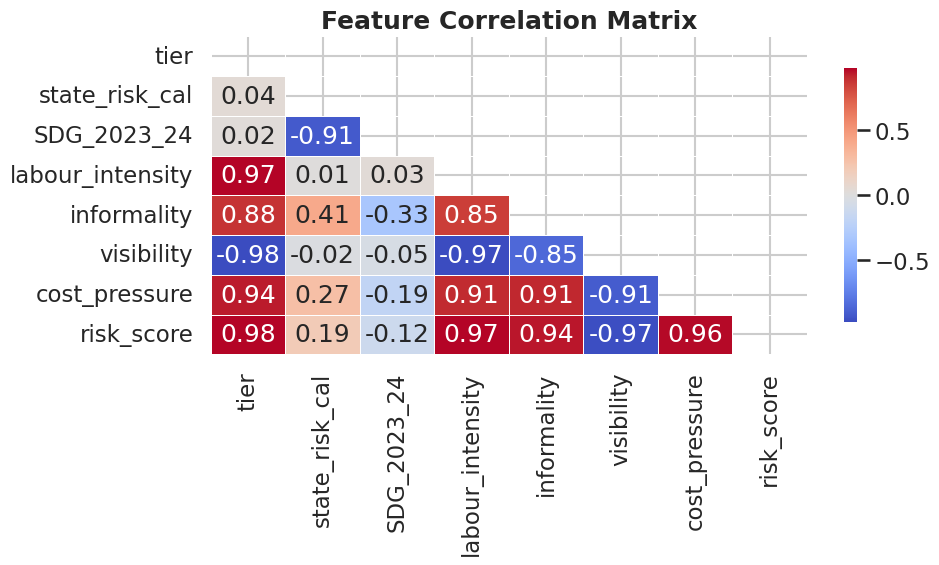

In [133]:
plt.figure(figsize=(10,6))

df_corr = test_df.drop(columns=[
    'supplier_id', 'state', 'cluster', 'stage', 'Unnamed: 0', 'high_risk'
])

corr = df_corr.corr()

# Create mask for upper triangle (including diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix", weight='bold')
plt.tight_layout()
plt.savefig("correlation_lower_triangle.png", dpi=300)
plt.show()

Axes(0.125,0.11;0.775x0.77)


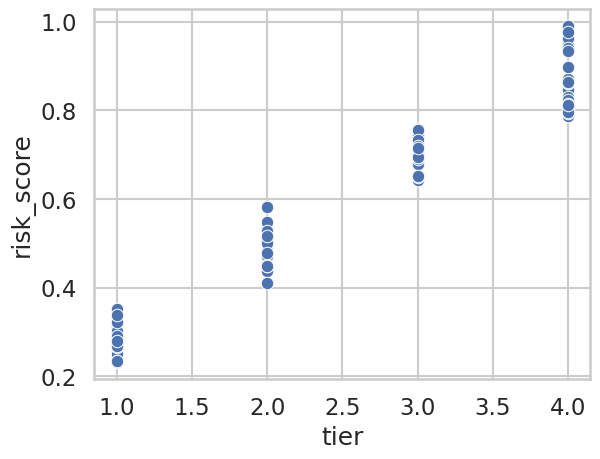

In [141]:
print(sns.scatterplot(data = test_df, y = 'risk_score', x = 'tier'))

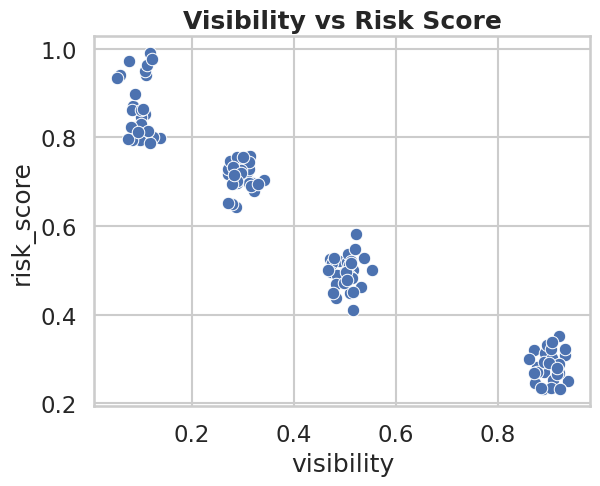

In [140]:
sns.scatterplot(x='visibility', y='risk_score', data=test_df)
plt.title("Visibility vs Risk Score", weight='bold')
plt.show()

/tmp/ipykernel_6354/1355512063.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6354/1355512063.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6354/1355512063.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6354/1355512063.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6354/1355512063.py:18: FutureWarning: 

P

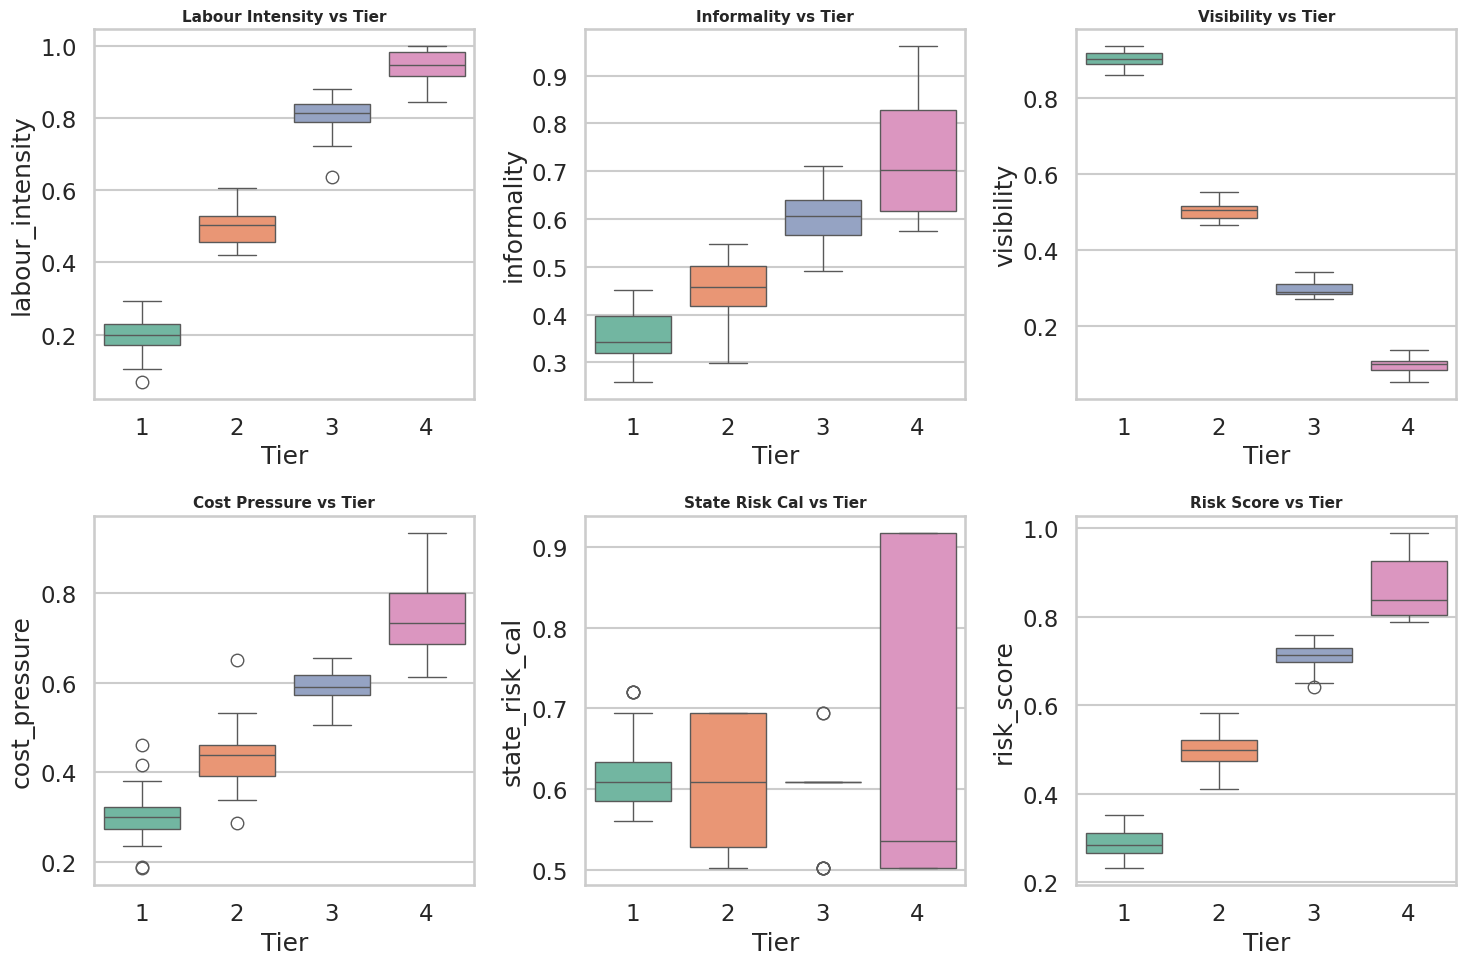

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'labour_intensity',
    'informality',
    'visibility',
    'cost_pressure',
    'state_risk_cal',
    'risk_score'
]

plt.figure(figsize=(15,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)

    sns.boxplot(
        x='tier',
        y=feature,
        data=test_df,
        palette='Set2'
    )

    plt.title(f"{feature.replace('_',' ').title()} vs Tier", fontsize=11, weight='bold')
    plt.xlabel("Tier")
    plt.ylabel(feature)

plt.tight_layout()
plt.savefig("tier_vs_features_boxplots.png", dpi=300)
plt.show()